### 🤸‍♂️💪 Gym Member Exercise - Decision Tree & Random Forest

# ℹ️ About Dataset 

This dataset provides a detailed overview of gym members' exercise routines, physical attributes, and fitness metrics. It contains 973 samples of gym data, including key performance indicators such as heart rate, calories burned, and workout duration. Each entry also includes demographic data and experience levels, allowing for comprehensive analysis of fitness patterns, athlete progression, and health trends.

# 🔑 Key Features 

* Age: Age of the gym member.
* Gender: Gender of the gym member (Male or Female).
* Weight (kg): Member’s weight in kilograms.
* Height (m): Member’s height in meters.
* Max_BPM: Maximum heart rate (beats per minute) during workout sessions.
* Avg_BPM: Average heart rate during workout sessions.
* Resting_BPM: Heart rate at rest before workout.
* Session_Duration (hours): Duration of each workout session in hours.
* Calories_Burned: Total calories burned during each session.
* Workout_Type: Type of workout performed (e.g., Cardio, Strength, Yoga, HIIT).
* Fat_Percentage: Body fat percentage of the member.
* Water_Intake (liters): Daily water intake during workouts.
* Workout_Frequency (days/week): Number of workout sessions per week.
* Experience_Level: Level of experience, from beginner (1) to expert (3).
* BMI: Body Mass Index, calculated from height and weight.

# Preblem we want to solve ❓

Predict `Experience level` . 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.metrics import precision_score , recall_score , f1_score 
from sklearn.metrics import RocCurveDisplay

## Load Data

In [28]:
data = pd.read_csv(r'C:\Users\stfal\OneDrive\Desktop\MachineLearning\Project-1\Lab3_DecisionTree_RandomForest\dataset\gym_members_exercise_tracking.csv')
data.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [4]:
data.isnull().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

In [5]:
experience_levels = data['Experience_Level'].value_counts().sort_index()
experience_levels

Experience_Level
1    376
2    406
3    191
Name: count, dtype: int64

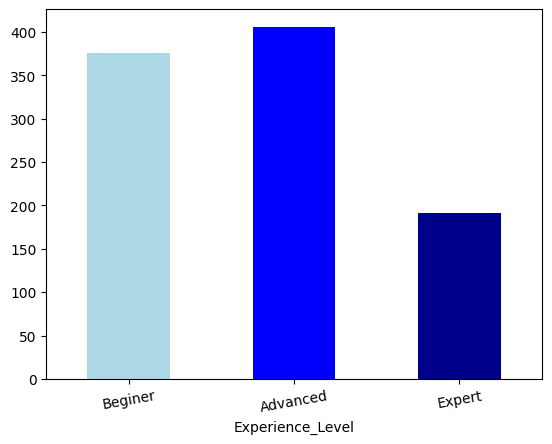

In [6]:
experience_levels.plot(kind='bar' , color=["lightblue" , "blue" , "darkblue"]);
plt.xticks(ticks=[0,1,2] , rotation=10 , labels = ['Beginer' , 'Advanced' , 'Expert'])
plt.show()

## OneHot Encoding

In [7]:
data.dtypes

Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

In [29]:
# Normalize data
for column in data.columns:
    if column == 'Experience_Level' : 
         continue
    if data[column].dtype == 'int64' or data[column].dtype == 'float64': 
        data[column] = (data[column] - data[column].min()) / (data[column].max() - data[column].min())

In [30]:
for column in data.columns :
    if data[column].dtype == 'object' : 
        print(column)

Gender
Workout_Type


In [31]:
unique_gender = np.unique(data['Gender'])
data['Gender'] = [np.argmax((g == unique_gender).astype(int)) for g in data['Gender']] 
unique_workout_type = np.unique(data['Workout_Type'])
data['Workout_Type'] = [np.argmax((t == unique_workout_type).astype(int)) for t in data['Workout_Type']]

In [32]:
data.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,0.926829,1,0.537264,0.42,0.512821,0.755102,0.416667,0.793333,0.682432,3,0.104,0.909091,0.666667,3,0.476546
1,0.682927,0,0.388209,0.06,0.487179,0.632653,0.666667,0.533333,0.391892,1,0.956,0.272727,0.666667,2,0.524520
2,0.341463,0,0.312570,0.32,0.179487,0.040816,0.166667,0.406667,0.252703,0,0.936,0.363636,0.666667,2,0.330224
3,0.170732,1,0.146830,0.40,0.769231,0.897959,0.250000,0.060000,0.154730,2,0.752,0.272727,0.333333,1,0.162313
4,0.487805,1,0.067853,0.58,0.717949,0.775510,0.750000,0.093333,0.170946,2,0.768,0.590909,0.333333,1,0.055171


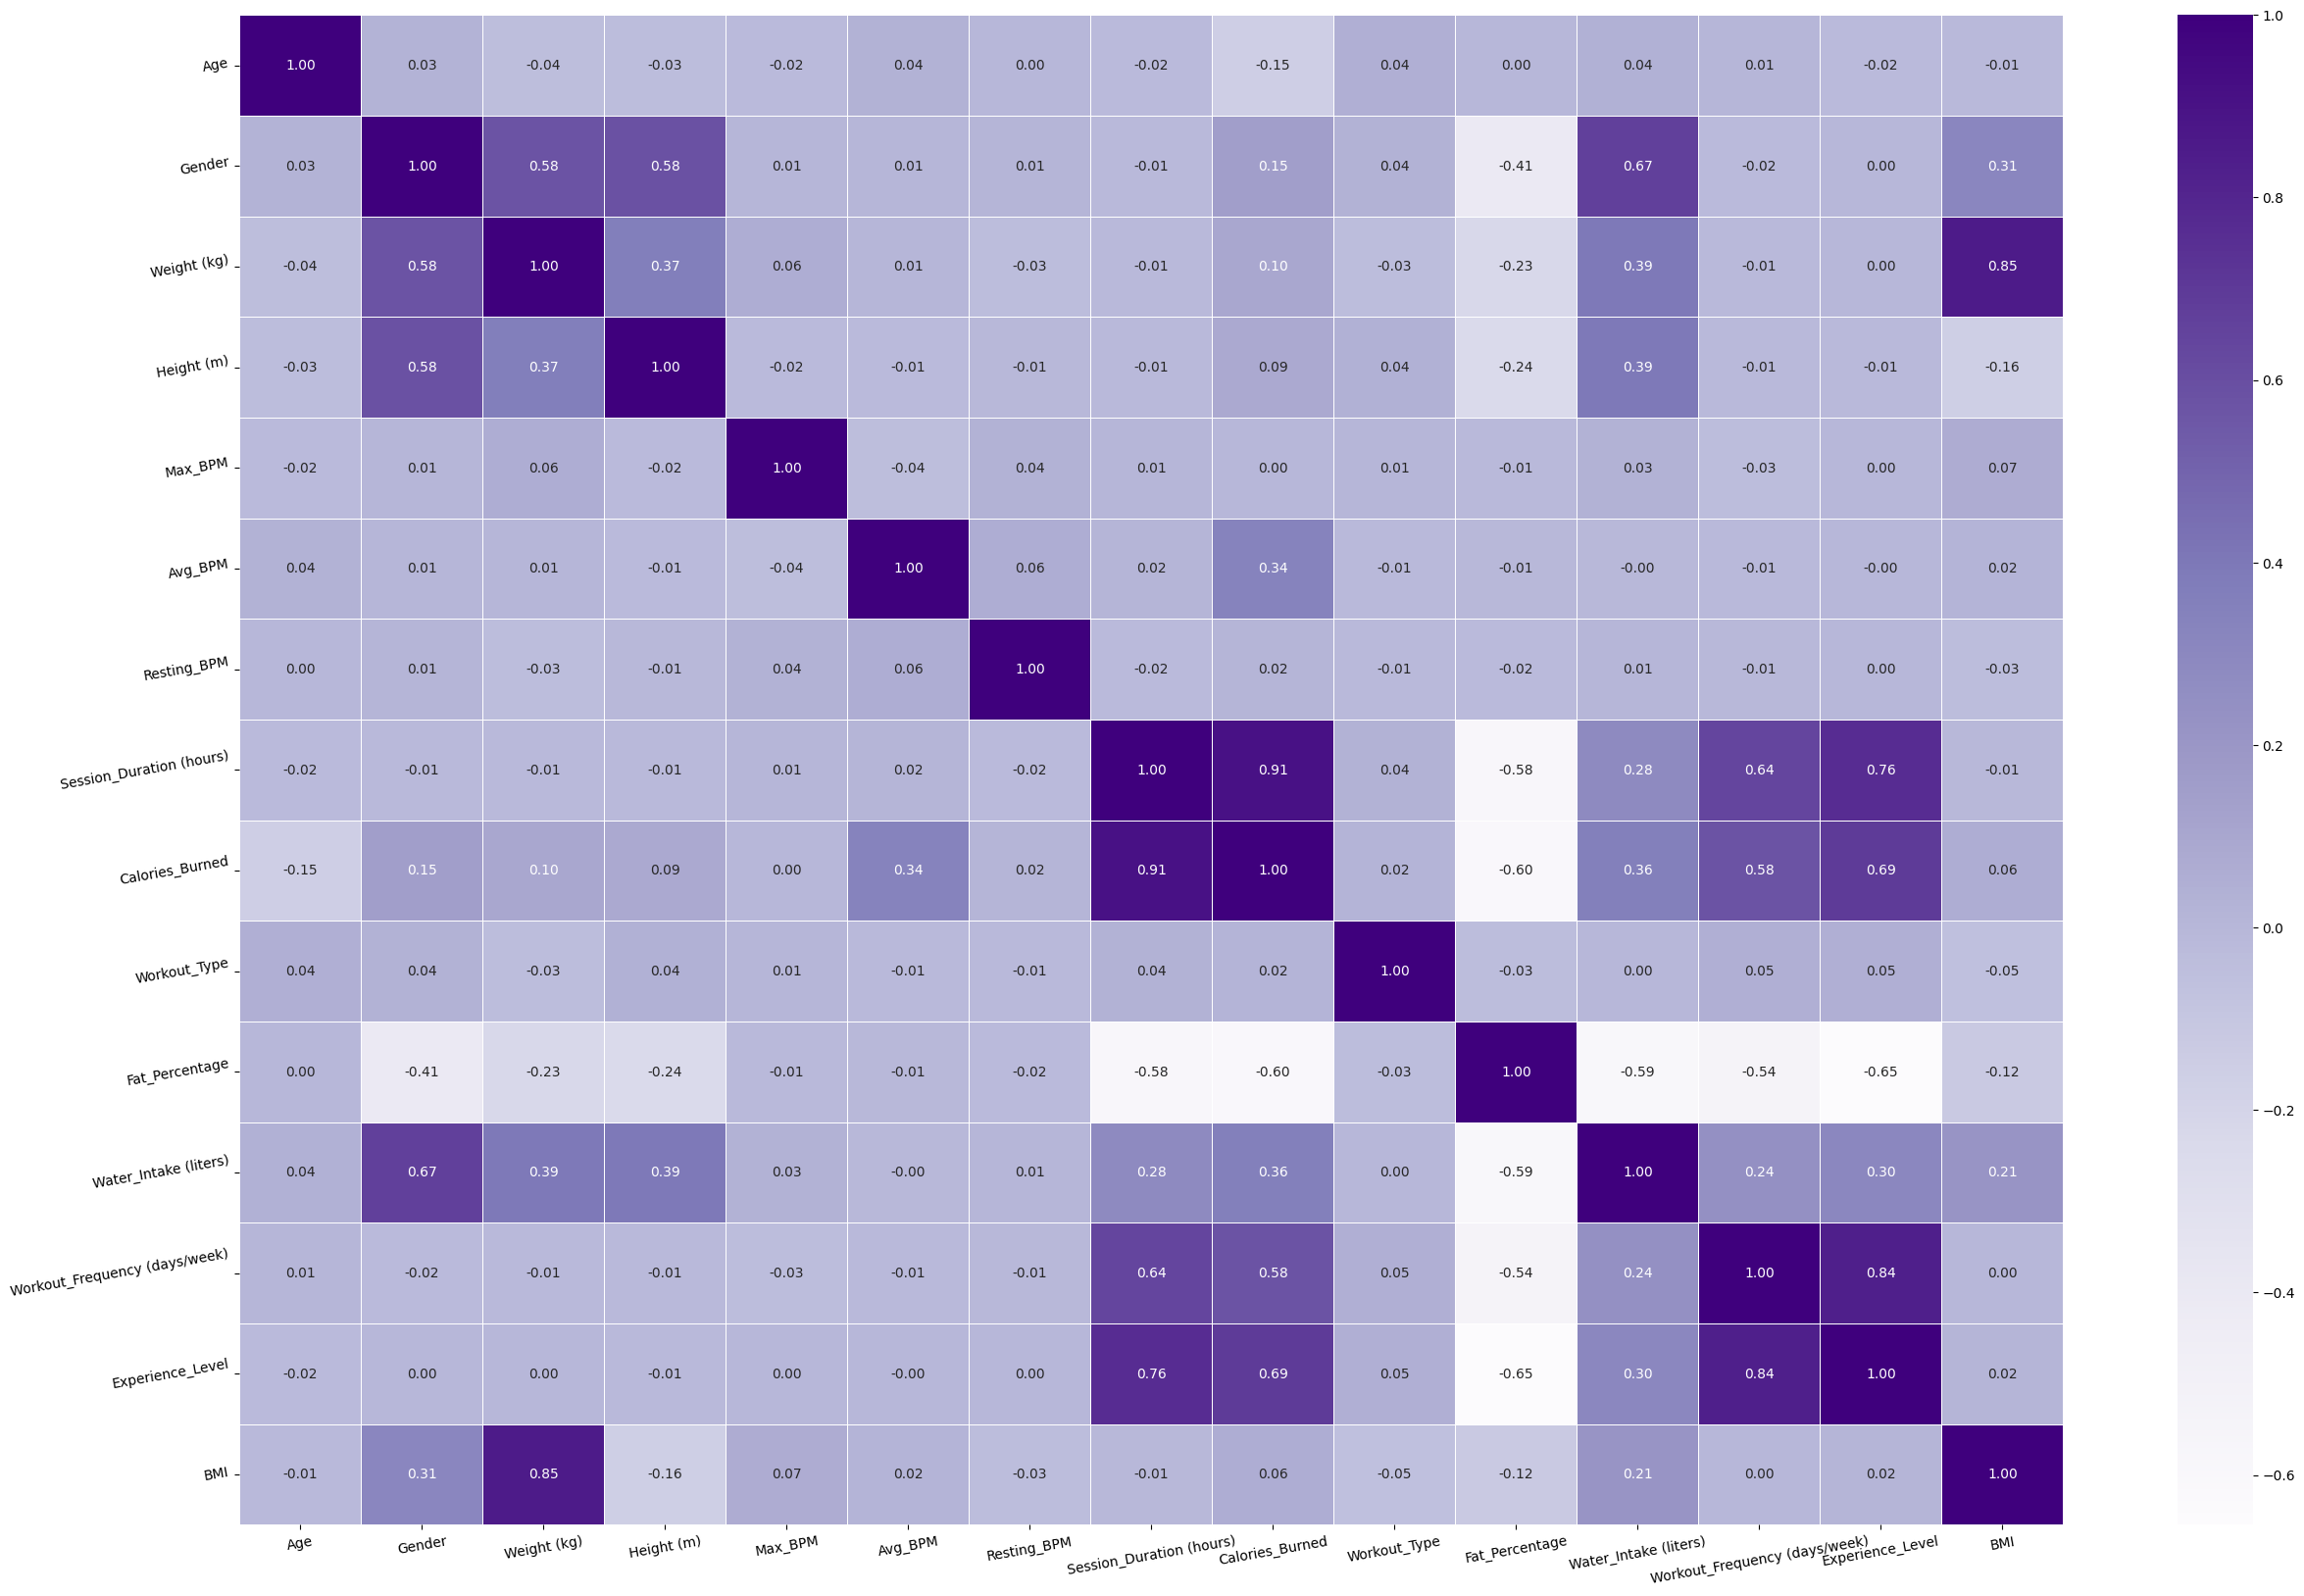

In [33]:
# Corelation matrix
corr_matrix = data.corr()
fig,ax = plt.subplots(figsize=(30,20));
ax = sns.heatmap(corr_matrix , annot=True , linewidths=0.5 , fmt=".2f" , cmap="Purples");
plt.xticks(rotation=10);
plt.yticks(rotation=10);
plt.show();

## Create X & y and split data

In [34]:
# Create X & y 
X = data.drop('Experience_Level' , axis=1)
y = data['Experience_Level']

In [35]:
# Split data 
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)
len(X_train) , len(y_train) , len(X_test) , len(y_test)

(778, 778, 195, 195)

## Decision Tree

In [63]:
from sklearn import tree
from sklearn.metrics import accuracy_score
import time

model = tree.DecisionTreeClassifier(max_depth=10 , random_state=42)
start_time = time.time()
model.fit(X_train , y_train)
end_time = time.time() - start_time
print(f'Train Time : {end_time*1000:.2f} ms')
train_score = model.score(X_train , y_train)
print(f'Train Score : {train_score*100:.1f}%')

Train Time : 7.30 ms
Train Score : 93.2%


In [64]:
y_pred = model.predict(X_test)
report = classification_report(y_test , y_pred)
print(report)
decision_tree_accuracy = accuracy_score(y_test , y_pred)

              precision    recall  f1-score   support

           1       0.92      0.86      0.89        78
           2       0.86      0.92      0.89        75
           3       1.00      1.00      1.00        42

    accuracy                           0.91       195
   macro avg       0.93      0.93      0.93       195
weighted avg       0.91      0.91      0.91       195



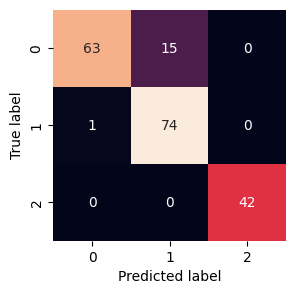

In [70]:
fig,ax = plt.subplots(figsize=(3,3))
ax = sns.heatmap(confusion_matrix(y_test,y_pred),
                     annot=True,
                     fmt='d',
                     cbar=False)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show();    

## Random Forest

In [65]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(max_depth=6 , random_state=42)
start_time = time.time()
model.fit(X_train , y_train)
end_time = time.time() - start_time

print(f'Train Time : {end_time*1000:.2f} ms')
train_score = model.score(X_train , y_train)
print(f'Train Score : {train_score*100:.1f}%')

Train Time : 154.39 ms
Train Score : 90.6%


In [67]:
y_pred = model.predict(X_test)
report = classification_report(y_test , y_pred)
print(report)
random_forest_accuracy = accuracy_score(y_test , y_pred)

              precision    recall  f1-score   support

           1       0.98      0.81      0.89        78
           2       0.83      0.99      0.90        75
           3       1.00      1.00      1.00        42

    accuracy                           0.92       195
   macro avg       0.94      0.93      0.93       195
weighted avg       0.93      0.92      0.92       195



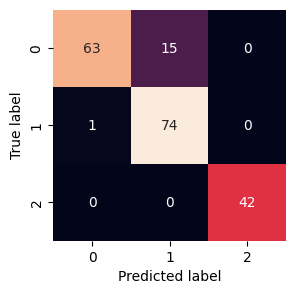

In [71]:
fig,ax = plt.subplots(figsize=(3,3))
ax = sns.heatmap(confusion_matrix(y_test,y_pred),
                     annot=True,
                     fmt='d',
                     cbar=False)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show();    

## Compare Decision Tree & Random Forest 

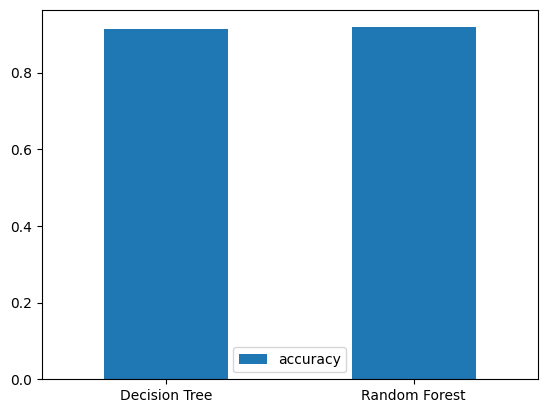

In [77]:
model_scores = {'Decision Tree' : decision_tree_accuracy , 'Random Forest' : random_forest_accuracy}

model_compare = pd.DataFrame(model_scores , index=['accuracy'])
model_compare.T.plot.bar()
plt.xticks(rotation=0)
plt.show()